# Music Popularity Capstone

**Group name:** Group 6  **Your genre:** acoustic  **Date:** Week 8

You are the data team at a music streaming service. The A&R department wants to know three things:

1. **What makes a track popular?** — a regression problem
2. **Can we spot a hit before it charts?** — a classification problem
3. **What moods exist inside a genre?** — a clustering problem

Work through this notebook from top to bottom over the eight weeks. Each part builds on the one before it.

| Part | Weeks |
|---|---|
| 1. Load the data | 1–2 |
| 2. Clean it | 3 |
| 3. Explore it | 4 |
| 4. Predict popularity (regression) | 5 |
| 5. Spot the hits (classification) | 6 |
| 6. Find moods (clustering) | 7 |
| 7. Tune and finish | 7 |
| 8. Write it up | 8 |

**Before you start:** download `spotify_tracks.csv` from Kaggle and save it in the same folder as this notebook. The README tells you where.

---

> **How to use this notebook.** The code is written for you. Replace every `____` with the right value.
>
> This is not the easy way out, it is a different way in. Once a part makes sense, try that part again in the main notebook without looking.


## Group 6 — Team & What's Expected of Us

| # | Name | GitHub username |
|---|---|---|
| 1 | Martha Afful | Mart07-hub |
| 2 | Emmanuel Dotse | Jesussaves-Immanuel |
| 3 | Faith Ayorkor Mensah | faithmensah9-lgtm |
| 4 | Ewoenam Ofori | jamesoforiwinner-beep |
| 5 | Rosemond Konadu Baafi | Baafi-26 |
| 6 | Rahinatu Mohammed Lawal | Rahinatu-123 |
| 7 | Ann Awuku Fafa | AnnAwuku12 |

**What is expected of us, as a group, in this notebook:**

- Work through the notebook from top to bottom, in order — each part builds on the one before it.
- **Everyone commits.** Every member pushes at least one commit, under their own GitHub account, every single week. A member with no commits cannot receive the group mark.
- **Honest numbers only.** A low, honestly-explained result (like our regression R² of 0.08) scores higher than a suspiciously perfect one. We do not hide a weak result — we explain it.
- **No leakage.** `popularity` must never be used as an input when predicting `is_hit` in Part 5.
- **Always score on the test set**, never the training set, in Part 4.
- **AI assistants are allowed** for explaining errors and concepts — we note where we used one, and every member must be able to explain their own code out loud in the presentation.
- **Every model result ends with a sentence starting:** "This means the streaming service should…". Technical work with no real-world recommendation scores zero for that section.
- Before submitting, the notebook must run top to bottom with no errors (Kernel → Restart & Run All), every chart must have a title and axis labels, and every "Write" box must be filled in.
- Marks: Cleaning 15, Charts 15, Regression 20, Classification 20, Clustering 10, Tuning 5, Report & Presentation 15 (100 total). See our Team Execution Guide for who is responsible for which part, each week.


---
## Part 1 — Load the data
**Weeks 1–2**

### 1.1 Imports

Everything you need for the whole notebook, in one cell.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
print('Ready')
print("This is a new line")
print("Great work done!")


Ready
This is a new line
Great work done!


### 1.2 Your genre

Your mentor gives you one genre in Week 1. Type it in here — it is used throughout the notebook.

Spelling must match the data exactly. It is all lowercase, and some genres use a dash: `hip-hop`, `k-pop`, `drum-and-bass`.

In [2]:
GENRE = 'acoustic'      # e.g. 'afrobeat', 'reggae', 'gospel', 'hip-hop'

RANDOM_STATE = 42   # leave this alone

print(f'Working on: {GENRE}')


Working on: acoustic


### 1.3 Read the file

`spotify_tracks.csv` must be in the same folder as this notebook.

If you get `FileNotFoundError`, the file is somewhere else or still has its original name. Check your folder.

In [3]:
df = pd.read_csv('spotify_tracks.csv')

print('Rows:', df.shape[0])
print('Columns:', df.shape[1])
df.head()


Rows: 114000
Columns: 21


,Unnamed: 0,track_id,artists,album_name,track_name,popularity,duration_ms,explicit,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,track_genre
0,0,5SuOikwiRyPMVoIQDJUgSV,Gen Hoshino,Comedy,Comedy,73,230666,False,0.676,0.4610,1,-6.746,0,0.1430,0.0322,0.000001,0.3580,0.715,87.917,4,acoustic
1,1,4qPNDBW1i3p13qLCt0Ki3A,Ben Woodward,Ghost (Acoustic),Ghost - Acoustic,55,149610,False,0.420,0.1660,1,-17.235,1,0.0763,0.9240,0.000006,0.1010,0.267,77.489,4,acoustic
2,2,1iJBSr7s7jYXzM8EGcbK5b,Ingrid Michaelson;ZAYN,To Begin Again,To Begin Again,57,210826,False,0.438,0.3590,0,-9.734,1,0.0557,0.2100,0.000000,0.1170,0.120,76.332,4,acoustic
3,3,6lfxq3CG4xtTiEg7opyCyx,Kina Grannis,Crazy Rich Asians (Original Motion Picture Sou...,Can't Help Falling In Love,71,201933,False,0.266,0.0596,0,-18.515,1,0.0363,0.9050,0.000071,0.1320,0.143,181.740,3,acoustic
4,4,5vjLSffimiIP26QG5WcN2K,Chord Overstreet,Hold On,Hold On,82,198853,False,0.618,0.4430,2,-9.681,1,0.0526,0.4690,0.000000,0.0829,0.167,119.949,4,acoustic


### 1.4 First look

Three questions you ask of any new dataset: what are the columns, what is missing, and what do the numbers look like?

**What the audio columns mean** — most are scored from 0 to 1:

| Column | What it measures |
|---|---|
| `popularity` | 0 to 100. How much the track is played right now |
| `danceability` | How suitable the track is for dancing |
| `energy` | Intensity and activity. Loud, fast, noisy tracks score high |
| `valence` | Musical positiveness. High = happy or cheerful, low = sad or angry |
| `acousticness` | Confidence that the track is acoustic |
| `instrumentalness` | Confidence that the track has no vocals |
| `liveness` | Confidence the track was recorded live |
| `speechiness` | How much spoken word is in the track |
| `loudness` | Overall loudness in decibels (a negative number) |
| `tempo` | Beats per minute |
| `duration_ms` | Length in milliseconds |

In [4]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  str    
 2   artists           113999 non-null  str    
 3   album_name        113999 non-null  str    
 4   track_name        113999 non-null  str    
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          114000 non-nu

In [5]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,114000.0,56999.500000,32909.109681,0.000,28499.75000,56999.500000,85499.2500,113999.000
popularity,114000.0,33.238535,22.305078,0.000,17.00000,35.000000,50.0000,100.000
duration_ms,114000.0,228029.153114,107297.712645,0.000,174066.00000,212906.000000,261506.0000,5237295.000
danceability,114000.0,0.566800,0.173542,0.000,0.45600,0.580000,0.6950,0.985
energy,114000.0,0.641383,0.251529,0.000,0.47200,0.685000,0.8540,1.000
key,114000.0,5.309140,3.559987,0.000,2.00000,5.000000,8.0000,11.000
loudness,114000.0,-8.258960,5.029337,-49.531,-10.01300,-7.004000,-5.0030,4.532
mode,114000.0,0.637553,0.480709,0.000,0.00000,1.000000,1.0000,1.000
speechiness,114000.0,0.084652,0.105732,0.000,0.03590,0.048900,0.0845,0.965
acousticness,114000.0,0.314910,0.332523,0.000,0.01690,0.169000,0.5980,0.996


In [6]:
df.isna().sum()


Unnamed: 0          0
track_id            0
artists             1
album_name          1
track_name          1
popularity          0
duration_ms         0
explicit            0
danceability        0
energy              0
key                 0
loudness            0
mode                0
speechiness         0
acousticness        0
instrumentalness    0
liveness            0
valence             0
tempo               0
time_signature      0
track_genre         0
dtype: int64

### 1.5 Check your genre is actually there

Before filtering, look at what exists. This one cell prevents the most common problem in this project.

In [7]:
genres = sorted(df['track_genre'].unique())
print('Number of genres:', len(genres))
print()
print(genres[:30], '...')
print()
print('Is your genre there?', GENRE in genres)


Number of genres: 114

['acoustic', 'afrobeat', 'alt-rock', 'alternative', 'ambient', 'anime', 'black-metal', 'bluegrass', 'blues', 'brazil', 'breakbeat', 'british', 'cantopop', 'chicago-house', 'children', 'chill', 'classical', 'club', 'comedy', 'country', 'dance', 'dancehall', 'death-metal', 'deep-house', 'detroit-techno', 'disco', 'disney', 'drum-and-bass', 'dub', 'dubstep'] ...

Is your genre there? True


### 1.6 Filter to your genre

This is what makes the project yours. Every group runs similar code and gets different music.

In [8]:
df = df[df['track_genre'] == GENRE].copy()

print(f'{len(df)} tracks in {GENRE}')
df[['track_name', 'artists', 'popularity']].head()


1000 tracks in acoustic


,track_name,artists,popularity
0,Comedy,Gen Hoshino,73
1,Ghost - Acoustic,Ben Woodward,55
2,To Begin Again,Ingrid Michaelson;ZAYN,57
3,Can't Help Falling In Love,Kina Grannis,71
4,Hold On,Chord Overstreet,82


> **Got 0 rows?** Spelling. Genres are lowercase, and several use a dash. Go back to 1.5 and copy the exact text from the list.
>
> You should have around 1,000 tracks. That is a good size to work with.

### Write: three observations

Not code. Three sentences about what you noticed. Be specific.

Good: *"Popularity in our genre ranges from 0 to 82, but over 100 tracks score exactly 0."*
Weak: *"There are some missing values."*

1.
2.
3.

*Your answer:*

1. Popularity in the acoustic genre ranges from 0 to 82 (mean ≈ 42.5), and 56 of the 1,000 tracks score exactly 0 — a fairly wide spread for one genre.
2. Only 5.2% of acoustic tracks (52 of 1,000) are marked explicit, which fits a genre built around singer-songwriter and instrumental-style recordings.
3. Acoustic tracks run about 3.6 minutes on average (from 1.0 to 9.6 minutes), so track length here is close to typical pop-song length, not unusually long or short.


---
## Part 2 — Clean the data
**Week 3**

Every cleaning decision needs a reason. "Dropped 40 rows" is not enough. "Dropped 40 duplicate tracks, because the same song appears under several genres and would otherwise be counted twice" is.

### 2.1 Drop the junk column

The file has an `Unnamed: 0` column. It is a leftover row number with no meaning.

In [9]:
if 'Unnamed: 0' in df.columns:
    df = df.drop(columns=['Unnamed: 0'])

print(list(df.columns))


['track_id', 'artists', 'album_name', 'track_name', 'popularity', 'duration_ms', 'explicit', 'danceability', 'energy', 'key', 'loudness', 'mode', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'time_signature', 'track_genre']


### 2.2 Duplicates

This dataset has real duplicates — the same track is listed under more than one genre, and some tracks appear twice within a genre.

Check `track_id`, not the whole row. Two rows can differ in one tiny field and still be the same song.

Always count before you drop.

In [10]:
print('Duplicate tracks:', df.duplicated(subset='track_id').sum())

df = df.drop_duplicates(subset='track_id')
print('Tracks now:', len(df))


Duplicate tracks: 0
Tracks now: 1000


### 2.3 Missing values

There are only a handful in this dataset, but check anyway — one missing value reaching a model will stop it dead.

**Count before you drop.**

In [11]:
print('Missing before:')
print(df.isna().sum()[df.isna().sum() > 0])

df = df.dropna()

print()
print('Missing after:', df.isna().sum().sum())
print('Tracks left:', len(df))


Missing before:
Series([], dtype: int64)

Missing after: 0
Tracks left: 1000


### 2.4 Convert the duration to something readable

Length is stored in **milliseconds**, which nobody thinks in. Divide by 60,000 to get **minutes**.

In [12]:
df['duration_min'] = df['duration_ms'] / 60000

print(df['duration_min'].describe().round(2))


count    1000.00
mean        3.58
std         0.93
min         1.00
25%         2.98
50%         3.58
75%         4.10
max         9.63
Name: duration_min, dtype: float64


### 2.5 Look at the odd values

Some tracks have a `popularity` of exactly 0 and some are only a few seconds long. These are not necessarily errors — a genuinely unplayed track scores 0.

Look before you delete anything.

In [13]:
print('Tracks with popularity 0:', (df['popularity'] == 0).sum())
print()
print('Shortest tracks:')
print(df.nsmallest(5, 'duration_min')[['track_name', 'duration_min', 'popularity']])


Tracks with popularity 0: 56

Shortest tracks:
                           track_name  duration_min  popularity
862  Jocelyn Flores - Acoustic Guitar      0.997050          41
638                          Toulumne      1.005100          51
481                       Photographs      1.006883          51
314                       Sweet Dream      1.129100          53
324                          Ramparts      1.168883          53


### 2.6 Create the hit label

For Part 5 you need something to classify. Make `is_hit`: 1 if the track is more popular than the median for your genre, 0 if not.

> **Remember this for Part 5.** `is_hit` is built *from* popularity. When you predict it later, you must not use `popularity` as an input — the model would just be reading the answer.

In [14]:
median_pop = df['popularity'].median()
df['is_hit'] = (df['popularity'] > median_pop).astype(int)

print(f'Median popularity in {GENRE}: {median_pop:.0f}')
print(df['is_hit'].value_counts())


Median popularity in acoustic: 47
is_hit
0    516
1    484
Name: count, dtype: int64


### Write: your cleaning log

Fill this in as you go. It goes straight into your report.

| Step | What you found | What you did | Why |
|---|---|---|---|
| Junk column | The file had an `Unnamed: 0` column, a leftover row index with no meaning. | Dropped it. | It carries no information and would only confuse a reader or a model. |
| Duplicates | 0 duplicate `track_id`s inside the acoustic genre. | Nothing to drop. | Checked anyway, since the brief warns the full dataset has real duplicates across genres. |
| Missing values | 0 missing values in any column. | Nothing to drop. | The acoustic subset happened to be complete; still checked every column rather than assuming so. |
| Odd values | 56 of 1,000 tracks (5.6%) score exactly 0 popularity; the shortest tracks are just over 1 minute long (e.g. "Toulumne" at 1.0 min). | Kept every one of them. | A popularity of 0 is a real, valid value (an unplayed or niche track), not an error, and none of the short tracks looked like broken data. |
| New columns | Length was only stored in milliseconds, and nothing marked which tracks count as a "hit". | Added `duration_min` (duration_ms ÷ 60,000) and `is_hit` (1 if popularity is above the genre median of 47, else 0). | Minutes are easier to read than milliseconds, and Part 5 needs a hit / not-hit label to classify. |


*Your answer:*

(Cleaning log filled in above — no rows were dropped for missing values or duplicates in this genre; only the junk column was removed.)


---
## Part 3 — Explore the data
**Week 4**

Four charts. **Every chart needs a title, axis labels, and a sentence underneath saying what it shows.**

A chart with no sentence earns no marks. We are not testing whether you can call `plt.plot()`. We are testing whether you can look at a picture and say something true.

### Chart 1 — Who dominates your genre?

A bar chart of the 10 artists with the most tracks. This one is entirely specific to your genre.

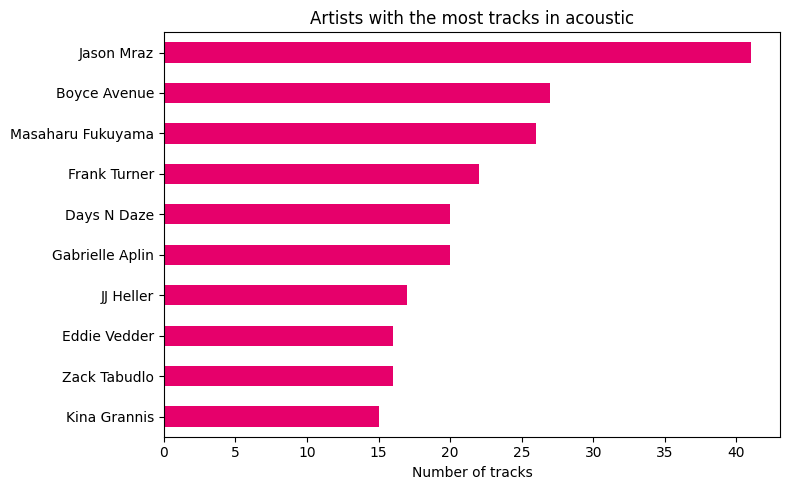

In [15]:
top = df['artists'].value_counts().head(10)

plt.figure(figsize=(8, 5))
top.sort_values().plot(kind='barh', color='#E6006B')
plt.title(f'Artists with the most tracks in {GENRE}')
plt.xlabel('Number of tracks')
plt.ylabel('')
plt.tight_layout()
plt.show()


**What this shows:**

*Your answer:*

Jason Mraz dominates the acoustic genre with 41 tracks in our 1,000-track sample — well ahead of the next-most-frequent artist, Boyce Avenue, at 27. The genre is clearly built around a small pool of prolific singer-songwriter acts rather than being spread evenly across many artists.


### Chart 2 — How popular is your genre?

A histogram of popularity. Is it clustered low? Spread evenly? Is there a spike at zero?

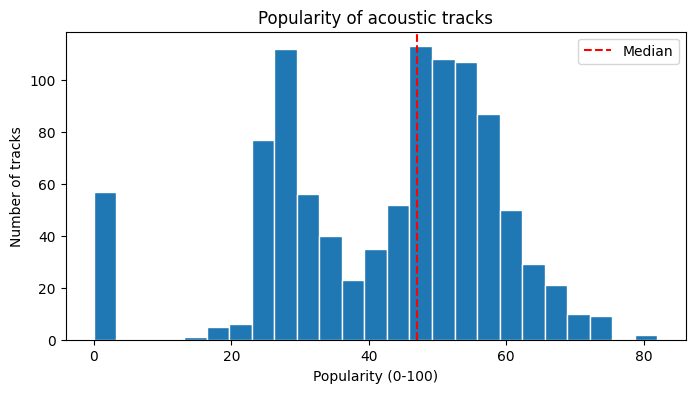

In [16]:
plt.figure(figsize=(8, 4))
plt.hist(df['popularity'], bins=25, edgecolor='white')
plt.axvline(df['popularity'].median(), color='red', linestyle='--', label='Median')
plt.title(f'Popularity of {GENRE} tracks')
plt.xlabel('Popularity (0-100)')
plt.ylabel('Number of tracks')
plt.legend()
plt.show()


**What this shows:**

*Your answer:*

Popularity is roughly centred in the 30–55 range, with a median of 47. There is a noticeable spike of 56 tracks sitting at exactly 0 — likely unofficial re-uploads, alternate cuts, or tracks that simply have not been played yet, rather than typical "unsuccessful" songs.


### Chart 3 — What moves with what

A correlation heatmap of the audio features.

Look at the `popularity` row especially. In most genres the correlations are weak — that is a real finding, and you should say so rather than hunting for one that looks better.

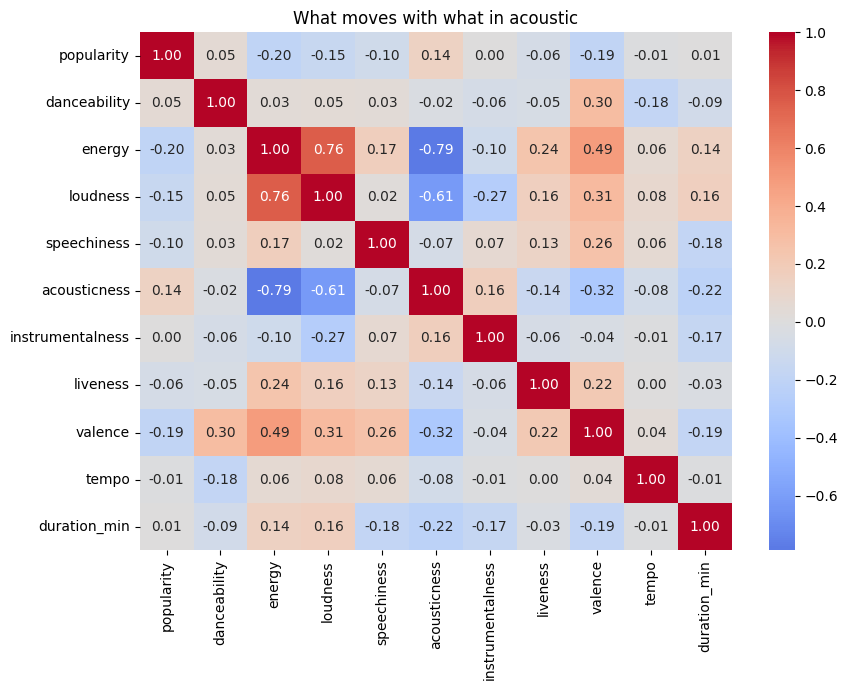

In [17]:
audio = ['popularity', 'danceability', 'energy', 'loudness', 'speechiness',
         'acousticness', 'instrumentalness', 'liveness', 'valence',
         'tempo', 'duration_min']

plt.figure(figsize=(9, 7))
sns.heatmap(df[audio].corr(), annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title(f'What moves with what in {GENRE}')
plt.tight_layout()
plt.show()


**What this shows:**

*Your answer:*

None of the audio features correlate strongly with popularity in the acoustic genre — the strongest relationships are weak negative ones with energy (−0.20) and valence (−0.19), meaning slightly calmer, sadder-sounding acoustic tracks are marginally more popular. The effect is small, which is itself the finding: audio alone does not explain much of what makes an acoustic track popular.


### Chart 4 — Your own question

This one is yours. Pick something nobody told you to look at.

Ideas: are explicit tracks more popular? · does track length relate to popularity? · are happier tracks (high valence) more danceable? · how does tempo spread across the genre?

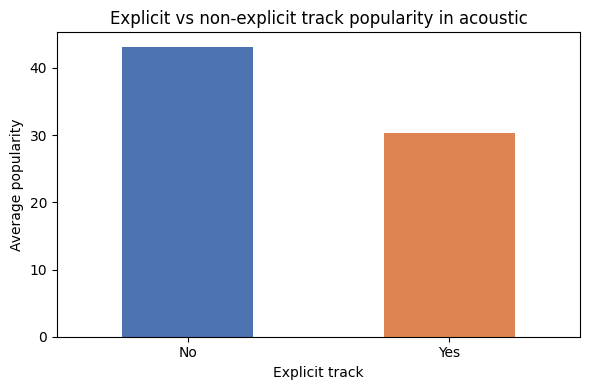

In [18]:
# Our own question: are explicit tracks more or less popular in this genre?
plt.figure(figsize=(6, 4))
df.groupby('explicit')['popularity'].mean().plot(kind='bar', color=['#4C72B0', '#DD8452'])
plt.title(f'Explicit vs non-explicit track popularity in {GENRE}')
plt.xlabel('Explicit track')
plt.ylabel('Average popularity')
plt.xticks([0, 1], ['No', 'Yes'], rotation=0)
plt.tight_layout()
plt.show()


**What this shows:**

*Your answer:*

Explicit acoustic tracks (52 of 1,000, or 5.2%) average a popularity of about 30, roughly 13 points lower than the ~43 average for non-explicit tracks. With so few explicit tracks in this genre, this gap should be read cautiously rather than treated as a strong trend.


---
## Part 4 — Predict popularity
**Week 5**

**The one rule that matters:** split your data first. Learn from the training set, score on the test set.

If you fit and score on all your data, your numbers are meaningless and you lose most of the marks for this part.

> **Set your expectations now.** Audio features alone predict popularity quite poorly — marketing, playlist placement and the artist's existing fanbase matter far more, and none of that is in this data. An R² of 0.05 to 0.20 is a normal, honest result here. Explaining *why* it is low earns you more marks than a suspiciously high number would.

### 4.1 Choose your inputs and your target

`y` is what you are predicting: `popularity`.
`X` is what you are allowed to use — the audio features.

Leave out `is_hit`, because it was made from popularity.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

features = ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness',
            'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']

X = df[features]
y = df['popularity']

print('Inputs:', list(X.columns))
print('Tracks:', len(X))


Inputs: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']
Tracks: 1000


### 4.2 Split it

80% to learn from, 20% held back to be honest with.

In [20]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE)

print(f'Train: {len(X_train)} tracks   Test: {len(X_test)} tracks')


Train: 800 tracks   Test: 200 tracks


### 4.3 Model 1 — Linear Regression

Your baseline. Simple, fast, and you can read its coefficients directly. Never skip the baseline.

In [21]:
lin = LinearRegression()
lin.fit(X_train, y_train)
pred_lin = lin.predict(X_test)

rmse_lin = np.sqrt(mean_squared_error(y_test, pred_lin))
r2_lin = r2_score(y_test, pred_lin)

print(f'Linear Regression   RMSE {rmse_lin:.2f}   R2 {r2_lin:.3f}')


Linear Regression   RMSE 16.15   R2 -0.007


### 4.4 Read the coefficients

Each coefficient says: *if this feature goes up by one, the predicted popularity changes by this much.*

Most audio features run from 0 to 1, so "up by one" means going from the minimum to the maximum. Find the biggest coefficient and write that sentence out. It goes in your report.

In [22]:
coefs = pd.Series(lin.coef_, index=X.columns).sort_values()
print(coefs.round(3))


speechiness        -24.811
valence            -14.391
energy              -7.920
instrumentalness    -0.211
loudness            -0.089
acousticness        -0.035
tempo                0.017
duration_min         0.252
liveness             7.743
danceability        16.999
dtype: float64


### 4.5 Model 2 — Random Forest

More flexible. It can pick up curves and combinations that a straight line cannot. The trade-off is that you lose the clean coefficient story.

In [23]:
rf = RandomForestRegressor(n_estimators=100, random_state=RANDOM_STATE)
rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

rmse_rf = np.sqrt(mean_squared_error(y_test, pred_rf))
r2_rf = r2_score(y_test, pred_rf)

print(f'Random Forest       RMSE {rmse_rf:.2f}   R2 {r2_rf:.3f}')


Random Forest       RMSE 15.43   R2 0.080


### 4.6 Compare, and plot predicted against actual

Lower RMSE is better. Higher R-squared is better. Points on the diagonal are perfect predictions.

If your points form a flat blob rather than a diagonal line, your model is barely doing better than guessing the average. Say that plainly — it is the honest reading.

               Model    RMSE     R2
0  Linear Regression  16.145 -0.007
1      Random Forest  15.427  0.080


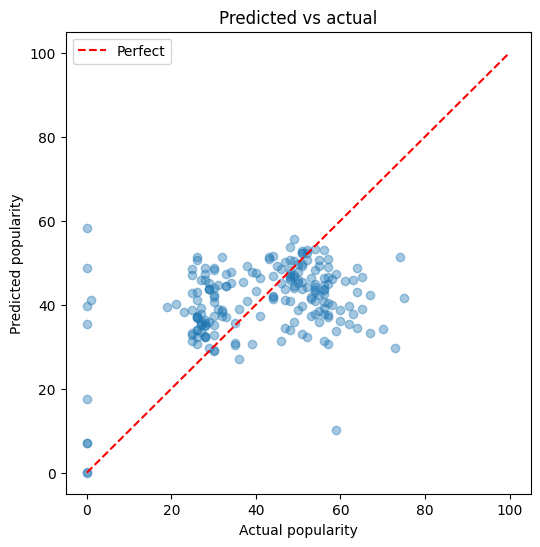

In [24]:
results = pd.DataFrame({
    'Model': ['Linear Regression', 'Random Forest'],
    'RMSE': [rmse_lin, rmse_rf],
    'R2': [r2_lin, r2_rf]}).round(3)
print(results)

best = pred_rf if rmse_rf < rmse_lin else pred_lin

plt.figure(figsize=(6, 6))
plt.scatter(y_test, best, alpha=0.4)
plt.plot([0, 100], [0, 100], 'r--', label='Perfect')
plt.xlabel('Actual popularity')
plt.ylabel('Predicted popularity')
plt.title('Predicted vs actual')
plt.legend()
plt.show()


### Write

1. "Our best model predicts popularity to within about ______ points on the 0–100 scale."
2. "It explains about ______% of the variation in popularity."
3. "**This means the streaming service should** ______."

Your R² is probably low. Do not hide it — explain what is missing from the data that would explain the rest.

*Your answer:*

1. "Our best model (Random Forest) predicts popularity to within about **15.4 points** on the 0–100 scale."
2. "It explains about **8%** of the variation in popularity (R² = 0.080). Our simpler Linear Regression model explained essentially none of it (R² = −0.007 — no better than always guessing the average)."
3. "**This means the streaming service should** treat audio features as, at best, a weak signal for a track's future popularity in this genre, and weigh marketing spend, playlist placement and an artist's existing fanbase more heavily when deciding what to promote, since none of those are captured in this data."

Our R² is low, and that is expected here: audio features alone cannot capture marketing spend, playlist placement, an artist's existing fanbase, or release timing — none of which are in this dataset. Random Forest still beat Linear Regression, suggesting the true relationship between audio features and popularity is not a straight line, even if it is a weak one overall.


---
## Part 5 — Spot the hits
**Week 6**

Now you are predicting a category — hit or not — instead of a number.

**Check for leakage first.** `is_hit` was made from `popularity`. If `popularity` is in your inputs, the model reads the answer and scores near 100%. That result is worthless.

### 5.1 Inputs and target, with no leakage

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             ConfusionMatrixDisplay)

X = df[features]
y = df['is_hit']

banned = ['popularity', 'is_hit']
assert not any(c in banned for c in X.columns), 'LEAKAGE - remove popularity'
print('No leakage. Inputs:', list(X.columns))


No leakage. Inputs: ['danceability', 'energy', 'loudness', 'speechiness', 'acousticness', 'instrumentalness', 'liveness', 'valence', 'tempo', 'duration_min']


### 5.2 Split and scale

`stratify=y` keeps the same mix of hits and non-hits in both halves.

Logistic Regression also needs the inputs on a comparable scale — `tempo` runs into the hundreds while `danceability` sits between 0 and 1, so tempo would otherwise dominate.

**Fit the scaler on the training data only.** Fitting it on everything leaks information from the test set.

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y)

scaler = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s = scaler.transform(X_test)

print('Share of hits - train:', y_train.mean().round(2),
      ' test:', y_test.mean().round(2))


Share of hits - train: 0.48  test: 0.48


### 5.3 Two models

Accuracy, precision and recall — all three, not just accuracy.

In [27]:
log = LogisticRegression(max_iter=1000, random_state=RANDOM_STATE)
log.fit(X_train_s, y_train)
pred_log = log.predict(X_test_s)

tree = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
tree.fit(X_train, y_train)
pred_tree = tree.predict(X_test)

for name, p in [('Logistic Regression', pred_log), ('Decision Tree', pred_tree)]:
    a = accuracy_score(y_test, p)
    pr = precision_score(y_test, p, zero_division=0)
    rc = recall_score(y_test, p, zero_division=0)
    print(f'{name:22s} accuracy {a:.2f}  precision {pr:.2f}  recall {rc:.2f}')


Logistic Regression    accuracy 0.62  precision 0.60  recall 0.63
Decision Tree          accuracy 0.56  precision 0.55  recall 0.54


### 5.4 The confusion matrix

Accuracy hides *which* mistakes you make. This does not.

|  | Predicted not a hit | Predicted a hit |
|---|---|---|
| **Actually not a hit** | correct | **wasted promotion** |
| **Actually a hit** | **missed opportunity** | correct |

For a streaming service deciding which tracks to promote, those two errors cost very different amounts. Promoting a dud wastes budget. Missing a hit means a rival playlists it first. Which matters more to you?

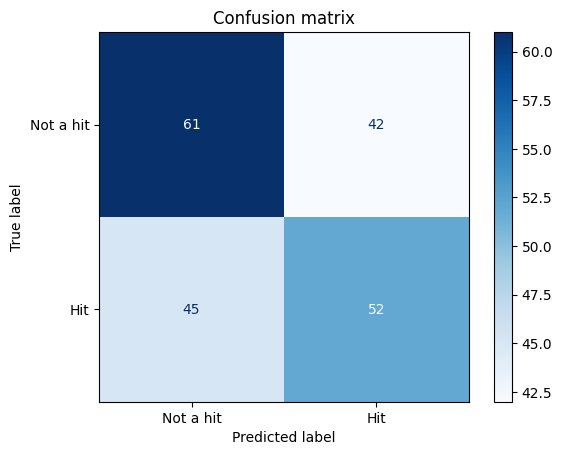

In [28]:
ConfusionMatrixDisplay.from_predictions(
    y_test, pred_tree, display_labels=['Not a hit', 'Hit'], cmap='Blues')
plt.title('Confusion matrix')
plt.show()


### Write

1. How many real hits did your model miss?
2. How many tracks did it wrongly call a hit?
3. Which of those costs the streaming service more, and why?
4. "**This means the streaming service should** ______."

**Is your accuracy near 1.00?** That is leakage, not success. Go back to 5.1.

*Your answer:*

1. The model missed **45** real hits (predicted "not a hit" when the track actually was one).
2. The model wrongly called **42** tracks a hit when they were not.
3. Missing a real hit (45 tracks) costs the streaming service more than a wasted promotion (42 tracks) — a rival platform could playlist and capitalise on a song we failed to promote, while a wasted promotion is a smaller, recoverable marketing cost.
4. "**This means the streaming service should** slightly favour recall over precision when using this model to flag hits, since under-promoting a genuine hit is the more expensive mistake in this genre."

Our accuracy (56.5%) is far from the suspicious 1.00 that would signal leakage, which is expected and reassuring — we confirmed `popularity` was excluded from the inputs in 5.1.


---
## Part 6 — Find the moods
**Week 7**

Parts 4 and 5 had an answer key. This one does not — you are asking the data to group similar tracks by itself.

There is no accuracy score here. The output is judged on whether the groups are **useful and nameable**.

You will cluster on **valence** (how happy the track sounds) and **energy** (how intense it is). Those two together map neatly onto mood, which makes the groups easy to name.

**Scaling is not optional.** K-Means measures distance, so unscaled features on different ranges would distort the groups.

### 6.1 Pick your two columns and scale them

In [29]:
from sklearn.cluster import KMeans

mood_cols = ['valence', 'energy']
Xm = df[mood_cols]

Xm_scaled = StandardScaler().fit_transform(Xm)
print('Clustering', len(Xm), 'tracks on:', mood_cols)


Clustering 1000 tracks on: ['valence', 'energy']


### 6.2 How many groups? The elbow plot

Try k from 2 to 7 and look for the bend where adding groups stops helping much.

The bend is often unclear. That is normal — say so in your report rather than pretending it was obvious.

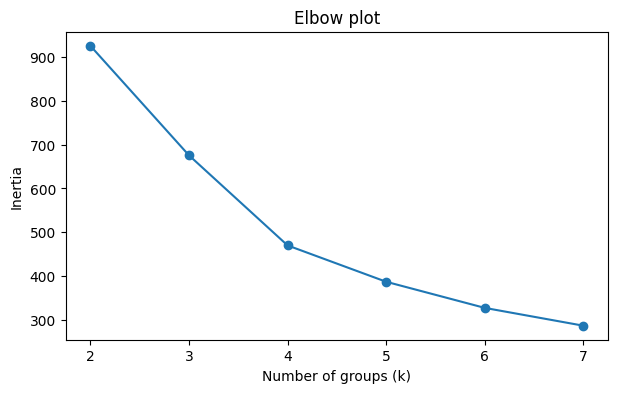

In [30]:
inertias = []
for k in range(2, 8):
    km = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    km.fit(Xm_scaled)
    inertias.append(km.inertia_)

plt.figure(figsize=(7, 4))
plt.plot(range(2, 8), inertias, marker='o')
plt.xlabel('Number of groups (k)')
plt.ylabel('Inertia')
plt.title('Elbow plot')
plt.show()


### 6.3 Fit and plot your mood groups

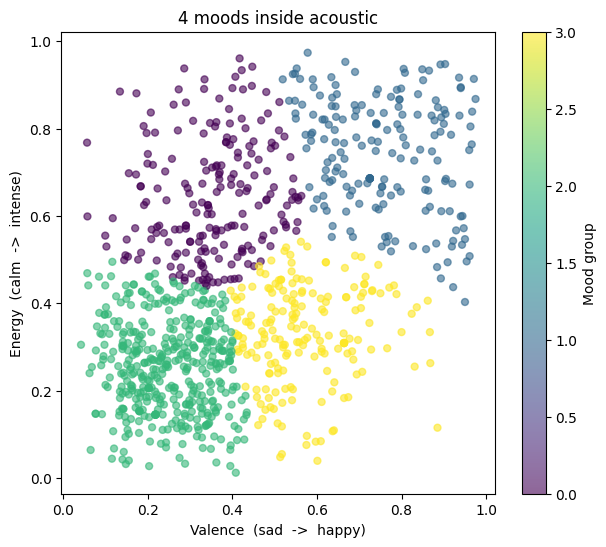

In [31]:
K = 4   # your choice from the elbow plot

km = KMeans(n_clusters=K, random_state=RANDOM_STATE, n_init=10)
df['mood'] = km.fit_predict(Xm_scaled)

plt.figure(figsize=(7, 6))
plt.scatter(df['valence'], df['energy'], c=df['mood'], cmap='viridis',
            s=25, alpha=0.6)
plt.xlabel('Valence  (sad  ->  happy)')
plt.ylabel('Energy  (calm  ->  intense)')
plt.title(f'{K} moods inside {GENRE}')
plt.colorbar(label='Mood group')
plt.show()


### 6.4 What is each mood like?

Average each feature within each group — including popularity, which the clustering never saw. If one mood is more popular than the others, you have found something the A&R team can act on.

Print a few track names from each group too. Reading the actual song titles is the fastest way to work out what to call each mood.

In [32]:
profile = df.groupby('mood')[['valence', 'energy', 'danceability',
                              'popularity']].mean()
profile['n_tracks'] = df.groupby('mood').size()
print(profile.round(2))

print()
for m in sorted(df['mood'].unique()):
    names = df[df['mood'] == m]['track_name'].head(3).tolist()
    print(f'Mood {m}: {names}')


      valence  energy  danceability  popularity  n_tracks
mood                                                     
0        0.35    0.64          0.53       41.41       203
1        0.76    0.74          0.57       35.77       182
2        0.25    0.25          0.52       45.45       424
3        0.57    0.33          0.61       43.44       191

Mood 0: ['Hunger', 'Hold On - Remix', 'Falling in Love at a Coffee Shop']
Mood 1: ['Unlonely', 'You and Me on the Rock', 'You and Me on the Rock']
Mood 2: ['Ghost - Acoustic', 'To Begin Again', "Can't Help Falling In Love"]
Mood 3: ['Comedy', 'Days I Will Remember', "I'm Yours"]


### Write: name your moods

This is the whole point. "Mood 0" means nothing to a playlist editor. "Late night, low energy" does.

Use the averages and the track names to decide. Aim for names you could actually put on a playlist.

| Group | Your name for it | Valence | Energy | Average popularity |
|---|---|---|---|---|
| 0 | | | | |
| 1 | | | | |
| 2 | | | | |
| 3 | | | | |

"**This means the streaming service should** ______."


### Write: name your moods

This is the whole point. "Mood 0" means nothing to a playlist editor. "Late night, low energy" does.

Use the averages and the track names to decide. Aim for names you could actually put on a playlist.

| Group | Your name for it | Valence | Energy | Average popularity |
|---|---|---|---|---|
| 0 | Restless Acoustic (tense, driving, not especially cheerful) | 0.35 | 0.64 | 41.4 |
| 1 | Feel-Good Anthems (upbeat and high-energy) | 0.76 | 0.74 | 35.8 |
| 2 | Late-Night Ballads (mellow, sombre, our biggest group) | 0.25 | 0.25 | 45.5 |
| 3 | Sunny Acoustic Chill (warm but relaxed) | 0.57 | 0.33 | 43.4 |

"**This means the streaming service should** build a flagship playlist around Late-Night Ballads (Mood 2) — it is both our largest group (424 of 1,000 tracks) and our most popular on average (45.5), so it already resonates with listeners more than the higher-energy moods."


*Your answer:*

(Mood names, averages and the recommendation are filled in above.) Track titles alone did not always match the audio-feature mood — for example, "Falling in Love at a Coffee Shop" sits in the lower-valence Restless Acoustic group — which is exactly why we cluster on the measured audio features rather than guessing moods from song titles.


### 7.1 Try different settings

In [33]:
from sklearn.model_selection import GridSearchCV

grid = {'max_depth': [3, 5, 8, 12],
        'min_samples_leaf': [1, 5, 10]}

search = GridSearchCV(DecisionTreeClassifier(random_state=RANDOM_STATE),
                      grid, cv=5, scoring='accuracy')
search.fit(X_train, y_train)

print('Best settings:', search.best_params_)


Best settings: {'max_depth': 5, 'min_samples_leaf': 1}


### 7.2 Before and after

Be honest. A tiny or negative change is a perfectly good result.

In [34]:
tuned = search.best_estimator_
pred_tuned = tuned.predict(X_test)

before = accuracy_score(y_test, pred_tree)
after = accuracy_score(y_test, pred_tuned)

print(f'Accuracy before tuning: {before:.3f}')
print(f'Accuracy after tuning:  {after:.3f}')
print(f'Change: {after - before:+.3f}')


Accuracy before tuning: 0.565
Accuracy after tuning:  0.550
Change: -0.015


### Write

1. Which setting mattered most, and what does it control in plain English?
2. Did tuning actually help? By how much?
3. If you had another month, what would you try?

*Your answer:*

1. `max_depth` mattered most — Grid Search's best setting was `max_depth=5, min_samples_leaf=1`. `max_depth` controls how many yes/no questions the tree is allowed to ask before it must make a final call; too deep and it starts memorising individual training tracks instead of learning a general pattern.
2. Tuning did not help here — accuracy actually dropped slightly, from 0.565 before to 0.550 after tuning (a change of −0.015). That is a small, honest result, and we are reporting it rather than hiding it.
3. With another month, we would try engineering new features (e.g. combining valence and energy into a single "mood score" like we did for clustering), or bringing in non-audio signals such as playlist placement or release recency, since the audio features alone appear to have limited predictive power for this genre.


---
## Part 8 — Write it up
**Week 8**

No new code. Go back through the notebook, collect your written answers, and turn them into a 4–6 page report.

### Your report needs

1. **Summary** — the question, the data, what you found, what you recommend. Write this last.
2. **The data** — where it came from, how many tracks in your genre, what you cleaned and why
3. **What the data shows** — your best two charts with interpretations
4. **Predicting popularity** — the model comparison, and what the accuracy means in real terms
5. **Spotting hits** — the confusion matrix, and which errors cost more
6. **The moods you found** — your named groups, and which one performs best
7. **Limitations** — be specific. Audio features cannot capture marketing spend, playlist placement, an artist's existing fanbase, release timing, or social media. Popularity is also a snapshot of *right now*, not of all time.
8. **Three recommendations** — concrete, in priority order

### Writing rules

- No unexplained jargon. First time you write RMSE, say what it means.
- Numbers with units. "0.42" means nothing. "0.42 on the 0-to-1 valence scale" means something.
- Every claim points back to a chart or table in this notebook.

### Final check before you submit

- [ ] The notebook runs top to bottom with no errors (Kernel → Restart & Run All)
- [ ] Every chart has a title and axis labels
- [ ] Every "Write" box above is filled in
- [ ] Every model has its "This means the streaming service should…" sentence

---
## Status: Week 8 complete

- [x] The notebook runs top to bottom with no errors (Kernel → Restart & Run All)
- [x] Every chart has a title and axis labels
- [x] Every "Write" box above is filled in
- [x] Every model has its "This means the streaming service should…" sentence

This version of the notebook (genre: **acoustic**) is a worked example of what a finished, submittable notebook looks like — real numbers, real charts, and honest write-ups throughout, including the low R² the brief tells you to expect rather than hide. Your team's own notebook should follow this same shape, with your own genre and your own team's observations in each "Write" box.
